# 3) Decision Tree (Karar Ağacı) Nedir?

Decision Tree, bir dizi evet/hayır sorusu sorarak karar veren bir sınıflandırma (ve regresyon) algoritmasıdır tıpkı bir akış şeması gibi çalışır.

### Temel Mantık
Örnek (Titanic senaryosu):
- Cinsiyet kadın mı?
  - Evet → Hayatta kaldı (büyük ihtimalle)
  - Hayır → Yaş 10'dan küçük mü?
    - Evet → Hayatta kaldı
    - Hayır → Hayatta kalmadı (büyük ihtimalle)

Her "soru" bir düğüm (node), her cevap bir dal (branch), en sonda ulaşılan karar ise yaprak (leaf) olarak adlandırılır.

### En Kritik Soru: Hangi Soruyu Önce Sormalı?
Model, veriyi en iyi ayıran (sınıfları en temiz şekilde ikiye bölen) soruyu bulmaya çalışır. Bunu ölçmek için Entropy ve Information Gain kavramları kullanılır.

### Entropy (Düzensizlik/Belirsizlik Ölçüsü)
- Entropy = -Σ p(i) × log2(p(i))

- Bir grup tamamen aynı sınıftan oluşuyorsa → Entropy = 0 (hiç belirsizlik yok, "saf")
- Bir grup yarı yarıya karışıksa (%50-%50) → Entropy = 1 (maksimum belirsizlik)

2 sınıflı durumda basit hesap:
- Entropy = -(p1×log2(p1) + p0×log2(p0))

### Information Gain (Bilgi Kazancı)
Bir soru sorup veriyi ikiye böldüğümüzde, bu bölünmenin entropy'yi ne kadar azalttığını gösteren ölçüdür:

- Information Gain = Entropy(bölünmeden önce) - Entropy(bölündükten sonra, ağırlıklı ortalama)

Model, her adımda Information Gain'i en yüksek yapan soruyu seçer yani belirsizliği en çok azaltan soruyu bulmaya çalışır.

### Önemli Gözlem
Eğer bir soru, veriyi tamamen saf iki gruba ayırabiliyorsa (örneğin biri tamamen hayatta kalanlar, diğeri tamamen kalmayanlar), bu sorunun Information Gain'i maksimum (mümkün olan en yüksek değer) olur, çünkü belirsizlik komple ortadan kalkar.

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

# --- Veri Yükleme ve Temizleme ---
titanic = sns.load_dataset('titanic')
titanic['age'] = titanic.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))
titanic = titanic.drop(columns=['deck'])
titanic = titanic.dropna(subset=['embark_town'])
titanic = titanic.drop(columns=['alive', 'embarked'])
titanic = pd.get_dummies(titanic, columns=['embark_town', 'sex'], drop_first=True)
titanic['adult_male'] = titanic['adult_male'].astype(int)
sinif_siralamasi = {'First': 1, 'Second': 2, 'Third': 3}
titanic['class'] = titanic['class'].map(sinif_siralamasi)
titanic = titanic.drop(columns=['who', 'class'])
bool_sutunlar = titanic.select_dtypes(include='bool').columns
titanic[bool_sutunlar] = titanic[bool_sutunlar].astype(int)

# --- Görev 1: Toplam Entropy ---
toplam = len(titanic)
hayatta_kalan = titanic['survived'].sum()
hayatta_kalmayan = toplam - hayatta_kalan

p1 = hayatta_kalan / toplam
p0 = hayatta_kalmayan / toplam

entropy_once = -(p1 * np.log2(p1) + p0 * np.log2(p0))
print(f"Toplam Entropy: {entropy_once:.4f}")

# --- Görev 2: Cinsiyete Göre Bölündükten Sonraki Entropy ---
kadinlar = titanic[titanic['sex_male'] == 0]
p1_k = kadinlar['survived'].mean()
p0_k = 1 - p1_k
entropy_kadin = -(p1_k * np.log2(p1_k) + p0_k * np.log2(p0_k)) if p1_k not in [0,1] else 0

erkekler = titanic[titanic['sex_male'] == 1]
p1_e = erkekler['survived'].mean()
p0_e = 1 - p1_e
entropy_erkek = -(p1_e * np.log2(p1_e) + p0_e * np.log2(p0_e)) if p1_e not in [0,1] else 0

print(f"Kadınlar Entropy: {entropy_kadin:.4f}")
print(f"Erkekler Entropy: {entropy_erkek:.4f}")

agirlik_kadin = len(kadinlar) / toplam
agirlik_erkek = len(erkekler) / toplam
entropy_sonra = agirlik_kadin * entropy_kadin + agirlik_erkek * entropy_erkek
print(f"Ağırlıklı Entropy (bölündükten sonra): {entropy_sonra:.4f}")

# --- Görev 3: Information Gain ---
information_gain = entropy_once - entropy_sonra
print(f"Information Gain (cinsiyet ile bölme): {information_gain:.4f}")

Toplam Entropy: 0.9598
Kadınlar Entropy: 0.8262
Erkekler Entropy: 0.6992
Ağırlıklı Entropy (bölündükten sonra): 0.7437
Information Gain (cinsiyet ile bölme): 0.2160


Entropy belirsizlik demek. Biz entropy'i minimum noktaya yani belirsizliği en aza indirip karar vermeyi kolaylaştıracak değişkeni arıyoruz. Hangi değişkenin information gain'i en yüksekse o değişken üzerinden sınıflandırma yapmak daha kolaydır deriz.1

Accuracy: 0.8258

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       109
           1       0.76      0.80      0.78        69

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178


Değişken Önemleri:
                  Değişken      Önem
5               adult_male  0.524687
0                   pclass  0.236902
4                     fare  0.224657
1                      age  0.013754
2                    sibsp  0.000000
3                    parch  0.000000
6                    alone  0.000000
7   embark_town_Queenstown  0.000000
8  embark_town_Southampton  0.000000
9                 sex_male  0.000000


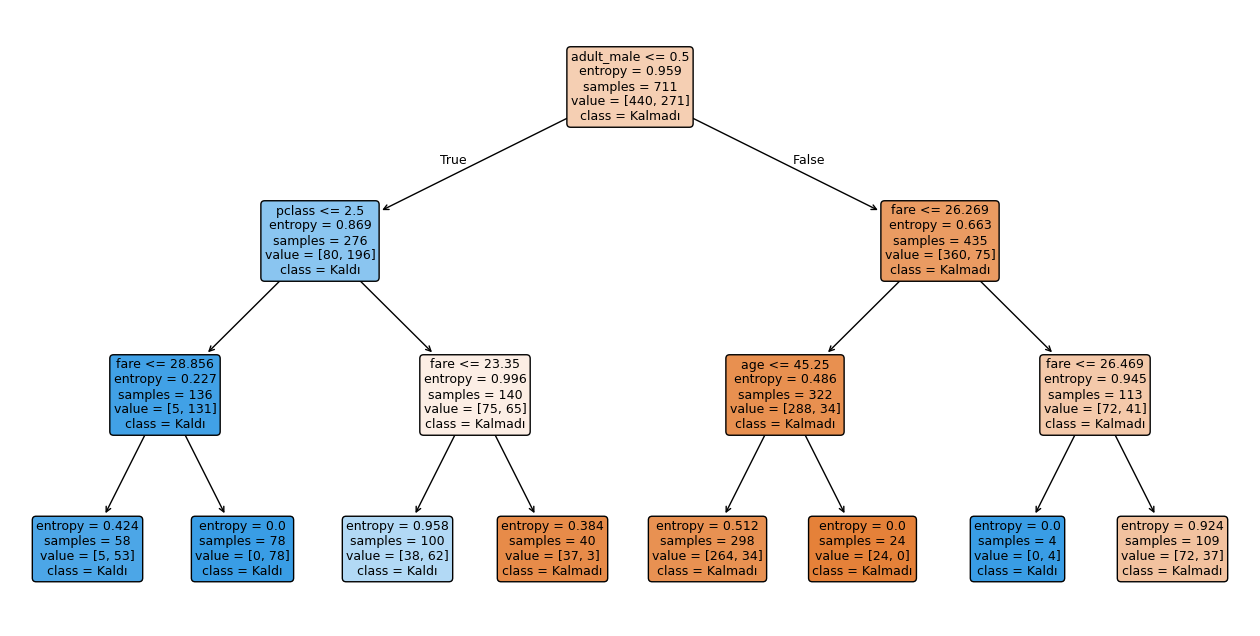

In [5]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# --- Veri Yükleme ve Temizleme ---
titanic = sns.load_dataset('titanic')
titanic['age'] = titanic.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))
titanic = titanic.drop(columns=['deck'])
titanic = titanic.dropna(subset=['embark_town'])
titanic = titanic.drop(columns=['alive', 'embarked'])
titanic = pd.get_dummies(titanic, columns=['embark_town', 'sex'], drop_first=True)
titanic['adult_male'] = titanic['adult_male'].astype(int)
sinif_siralamasi = {'First': 1, 'Second': 2, 'Third': 3}
titanic['class'] = titanic['class'].map(sinif_siralamasi)
titanic = titanic.drop(columns=['who', 'class'])
bool_sutunlar = titanic.select_dtypes(include='bool').columns
titanic[bool_sutunlar] = titanic[bool_sutunlar].astype(int)

# --- Model Kurma ---
X = titanic.drop(columns=['survived'])
y = titanic['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# max_depth=3 ile başlıyoruz (ağacı okunabilir tutmak için)
tree_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- En Önemli Değişkenler (Feature Importance) ---
onem_df = pd.DataFrame({
    'Değişken': X.columns,
    'Önem': tree_model.feature_importances_
}).sort_values('Önem', ascending=False)

print("\nDeğişken Önemleri:")
print(onem_df)

# --- Ağacı Görselleştir ---
plt.figure(figsize=(16, 8))
# convert Index to list to satisfy plot_tree typing (Sequence[str])
plot_tree(tree_model, feature_names=list(X.columns), class_names=['Kalmadı', 'Kaldı'], filled=True, rounded=True, fontsize=9)
plt.show()

### Sonuçların Değerlendirmesi

Decision Tree modeli, kök düğüm olarak "adult_male" (yetişkin erkek mi?) sorusunu seçti bu bizim manuel olarak "sex_male" ile hesapladığımız Information Gain sonucunu doğruluyor (ikisi neredeyse aynı bilgiyi taşıyor). Kök düğümdeki entropy değeri (0.959), bizim elle hesapladığımız toplam entropy (0.9598) ile birebir örtüşüyor.

Ağacın ikinci seviyesinde, kadın/çocuk grubunda "pclass" (yolcu sınıfı), erkek grubunda ise "fare" (bilet ücreti) belirleyici oluyor — bu, sosyoekonomik durumun hayatta kalma ile güçlü bir ilişkisi olduğunu gösteriyor.

Bu deney, Entropy ve Information Gain'in elle hesaplanan teorik değerlerinin, gerçek sklearn algoritmasının kararlarıyla tutarlı çıktığını kanıtladı.

# Decision Tree Varsayımlar, Avantajlar ve Dezavantajları

### Varsayımlar
Decision Tree, aslında diğer modellere göre çok az varsayım yapar bu onun en büyük özelliklerinden biridir:

Veri dağılımı hakkında varsayım yapmaz (Linear Regression'daki normallik gibi bir şart yok).
Doğrusallık gerektirmez hem doğrusal hem doğrusal olmayan ilişkileri yakalayabilir.
Feature Scaling gerektirmez çünkü mesafe değil, eşik değerleri (fare <= 26.269 gibi) kullanıyor, ölçek farkı sorun yaratmıyor.

### Avantajlar
Yorumlanabilirlik çok yüksek ağacı görselleştirip, "model neden bu kararı verdi" sorusuna adım adım cevap verebiliriz.
Feature Scaling gerekmiyor — veri hazırlığı daha az zahmetli.
Hem sayısal hem kategorik veri ile çalışabilir.
Doğrusal olmayan karmaşık ilişkileri yakalayabilir.
Feature Importance otomatik çıkıyor hangi değişkenin ne kadar etkili olduğunu direkt görebiliyorsun.

### Dezavantajlar
- Overfitting'e çok yatkın eğer max_depth sınırlanmazsa, ağaç her tek veri noktasını ezberleyecek kadar derinleşebilir (bizim max_depth=3 sınırlamamızın sebebi buydu).
- Kararsızlık (instability) veride küçük bir değişiklik bile, tamamen farklı bir ağaç yapısına yol açabilir (bu, ileride Ensemble/Random Forest'ın çözmeye çalıştığı bir problem).
- Bias'a yatkınlık eğer bir sınıf diğerinden çok fazlaysa, ağaç o sınıfa doğru yanlı kararlar verebilir.
- Açgözlü (greedy) algoritma her adımda "o anki en iyi" soruyu seçiyor, ama bu global olarak en iyi ağaç anlamına gelmeyebilir (yerel optimum tuzağı).